<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/(DE_LOS_REYES)Discussion_5_1_Random_Forest_using_GridSearch_and_RandomSearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bagging Exercises

## Introduction

We will be using the customer churn data from the telecom industry that we used in week 1 for this week's exercises. The data file is called `Orange_Telecom_Churn_Data.csv`.

In [ ]:
from __future__ import print_function
import os
data_path = ['..', '..', 'data']

## Question 1

* Import the customer churn data, which is found in the file `Orange_Telecom_Churn_Data.csv`.
* Remove any columns that are likely not to be used for prediction.
* Encode data types as appropriate.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
filepath = '/content/Orange_Telecom_Churn_Data.csv'

In [ ]:
import pandas as pd
import numpy as np


data = pd.read_csv(filepath, sep=',')

In [ ]:
data.head().T

,0,1,2,3,4
state,KS,OH,NJ,OH,OK
account_length,128,107,137,84,75
area_code,415,415,415,408,415
phone_number,382-4657,371-7191,358-1921,375-9999,330-6626
intl_plan,no,no,no,yes,yes
voice_mail_plan,yes,yes,no,no,no
number_vmail_messages,25,26,0,0,0
total_day_minutes,265.1,161.6,243.4,299.4,166.7
total_day_calls,110,123,114,71,113
total_day_charge,45.07,27.47,41.38,50.9,28.34


The prediction should definitely not include phone number. And it is unlikely that area code or state would be desired, unless there is some reason to assume the model has a very specific geographic factor.

In [ ]:
data.drop(['state', 'phone_number', 'area_code'], axis=1, inplace=True)

Examine the data types. Everything looks OK other than `int_plan` and `voice_mail_plan` need to be boolean encoded.

In [ ]:
data.dtypes

,0
account_length,int64
intl_plan,object
voice_mail_plan,object
number_vmail_messages,int64
total_day_minutes,float64
total_day_calls,int64
total_day_charge,float64
total_eve_minutes,float64
total_eve_calls,int64
total_eve_charge,float64


In [ ]:
for col in ['intl_plan', 'voice_mail_plan']:
    data[col] = data[col].replace('yes','True').replace('no','False').astype(bool)


data[['intl_plan', 'voice_mail_plan']].dtypes

,0
intl_plan,bool
voice_mail_plan,bool


## Question 2

* Examine distribution of the predicted variable (`churned`).
* Split the data into train and test sets. Decide if a stratified split should be used or not based on the distribution.
* Examine the distribution of the predictor variable in the train and test data.

In [ ]:
# Data are skewed at ~85% towards non-churned customers
# This will be important to remember when model building

data.churned.value_counts()

,count
churned,
False,4293
True,707


In [ ]:
data.churned.value_counts(normalize=True)

,proportion
churned,
False,0.8586
True,0.1414


Given the skew in the predictor variable, let's split the data with the *churned* values being stratified.

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit


feature_cols = [x for x in data.columns if x != 'churned']


# Split the data into two parts with 1500 points in the test data
# This creates a generator
strat_shuff_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the index values from the generator
train_idx, test_idx = next(strat_shuff_split.split(data[feature_cols], data['churned']))

# Create the data sets
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'churned']

X_test = data.loc[test_idx, feature_cols]
y_test = data.loc[test_idx, 'churned']

In [ ]:
y_train.value_counts(normalize=True)

,proportion
churned,
False,0.8585
True,0.1415


In [ ]:
y_test.value_counts(normalize=True)

,proportion
churned,
False,0.859
True,0.141


## Question 3

* Fit random forest models with a range of tree numbers and evaluate the out-of-bag error for each of these models.
* Plot the resulting oob errors as a function of the number of trees.

*Hint:* since the only thing changing is the number of trees, the `warm_start` flag can be used so that the model just adds more trees to the existing model each time. Use the `set_params` method to update the number of trees.

In [ ]:
# Suppress warnings about too few trees from the early models

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the random forest estimator
# Note that the number of trees is not setup here
RF = RandomForestClassifier(oob_score=True,
                            random_state=42,
                            warm_start=True,
                            n_jobs=-1)

oob_list = list()

# Iterate through all of the possibilities for
# number of trees
for n_trees in [15, 20, 30, 40, 50, 100, 150, 200, 300, 400,600,800]:

    # Use this to set the number of trees
    RF.set_params(n_estimators=n_trees)

    # Fit the model
    RF.fit(X_train, y_train)

    # Get the oob error
    oob_error = 1 - RF.oob_score_

    # Store it
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))

rf_oob_df = pd.concat(oob_list, axis=1).T.set_index('n_trees')

rf_oob_df

,oob
n_trees,
15.0,0.08700
20.0,0.08150
30.0,0.07650
40.0,0.07500
50.0,0.07350
100.0,0.07025
150.0,0.07125
200.0,0.07000
300.0,0.06925


The error looks like it has stabilized around 100-150 trees.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

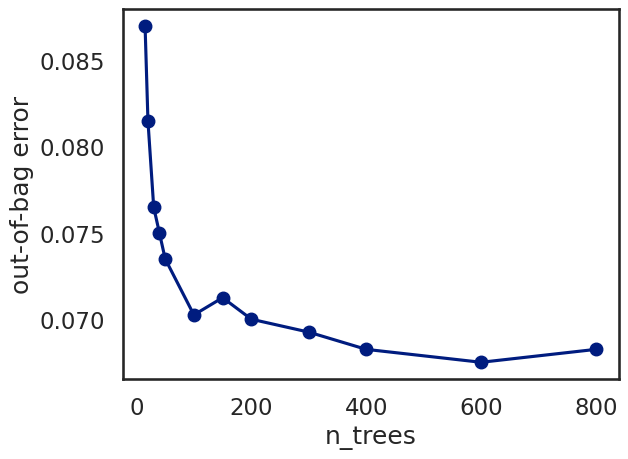

In [ ]:
sns.set_context('talk')
sns.set_palette('dark')
sns.set_style('white')

ax = rf_oob_df.plot(legend=False, marker='o')
ax.set(ylabel='out-of-bag error');

In [ ]:
#import necessary libraries
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Using GridSearch and RandomSearch choose the best parameter for random forest model
rfc = RandomForestClassifier(random_state= 42)

In [ ]:
#Setting up GridSearch parameters for Random Forest
param_grid = {
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [10,20,30],
    'criterion' :['gini', 'entropy']
}
param_dist = {
    'n_estimators': [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [int(x) for x in np.linspace(10, 110, num = 11)],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}


In [ ]:
#Perform GridSearchCV for RandomForest
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 500]})

In [ ]:
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 20,
 'max_features': 'sqrt',
 'n_estimators': 200}

In [ ]:
grid_search.best_score_

0.93075

In [ ]:
random_search = RandomizedSearchCV(estimator=rfc, param_distributions=param_dist,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=42, verbose=2)

In [ ]:
random_search.best_params_

{'n_estimators': 2000,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 70,
 'bootstrap': True}

In [ ]:
random_search.best_score_

0.9279998035490881

In [ ]:
# Evaluate performance
def evaluate_model(search, X_train, X_test, y_train, y_test, name):
    print(f"Results for {name} Search")
    # Training set performance
    y_train_pred = search.predict(X_train)
    print(f"Training Accuracy: {search.score(X_train, y_train):.4f}")
    print("Training Classification Report:")
    print(classification_report(y_train, y_train_pred))

    # Testing set performance
    y_test_pred = search.predict(X_test)
    print(f"Testing Accuracy: {search.score(X_test, y_test):.4f}")
    print("Testing Classification Report:")
    print(classification_report(y_test, y_test_pred))

    # Confusion matrix for test set
    print(f"Confusion Matrix (Test Set) for {name}:")
    print(confusion_matrix(y_test, y_test_pred))

    # AUC-ROC score and curve
    if len(np.unique(y_test)) == 2:
        auc_score = roc_auc_score(y_test, search.predict_proba(X_test)[:, 1])
        print(f"AUC-ROC (Test Set) for {name}: {auc_score:.4f}")

        fpr, tpr, _ = roc_curve(y_test, search.predict_proba(X_test)[:, 1])
        plt.plot(fpr, tpr, label=f'{name} Search (AUC = {auc_score:.4f})')
    else:
        print(f"{name} AUC-ROC not available for multi-class classification")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,roc_curve

Results for Grid Search
Training Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3434
        True       1.00      1.00      1.00       566

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

Testing Accuracy: 0.9270
Testing Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.99      0.96       859
        True       0.90      0.55      0.68       141

    accuracy                           0.93      1000
   macro avg       0.91      0.77      0.82      1000
weighted avg       0.93      0.93      0.92      1000

Confusion Matrix (Test Set) for Grid:
[[850   9]
 [ 64  77]]
AUC-ROC (Test Set) for Grid: 0.8582


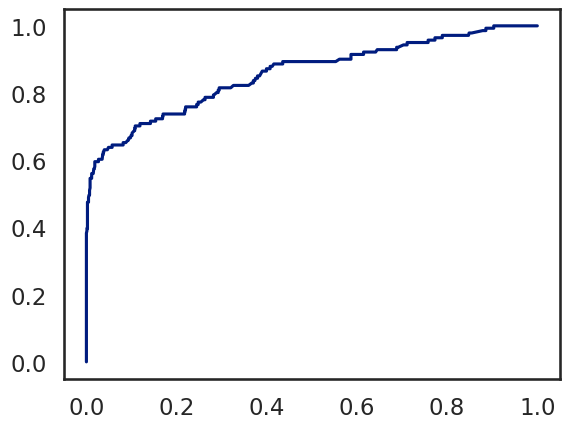

In [ ]:
evaluate_model(grid_search, X_train, X_test, y_train, y_test, 'Grid')

Results for Random Search
Training Accuracy: 0.9875
Training Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99      3434
        True       1.00      0.91      0.95       566

    accuracy                           0.99      4000
   macro avg       0.99      0.96      0.97      4000
weighted avg       0.99      0.99      0.99      4000

Testing Accuracy: 0.9300
Testing Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.99      0.96       859
        True       0.92      0.55      0.69       141

    accuracy                           0.93      1000
   macro avg       0.92      0.77      0.83      1000
weighted avg       0.93      0.93      0.92      1000

Confusion Matrix (Test Set) for Random:
[[852   7]
 [ 63  78]]
AUC-ROC (Test Set) for Random: 0.8624


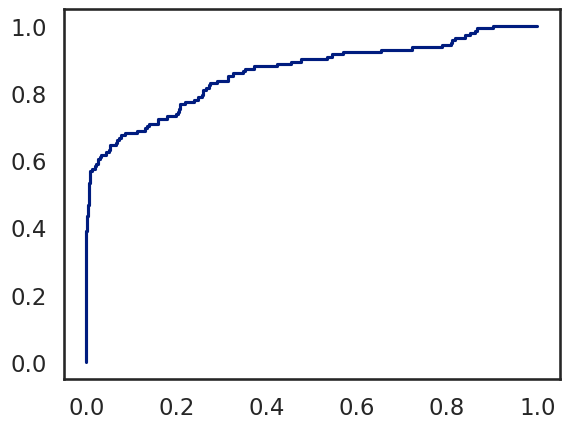

In [ ]:
evaluate_model(random_search, X_train, X_test, y_train, y_test, "Random")

###**Interpretation**

In this activity we evaluate the Random Forest model performance and find the best parameters using GridSearchCV and RandomizedSearch. As we get to the accuracy of the training and testing, I notice that the GridSearchCV got a 1.0 accuracy on training and  0.9270 on testing. Thus, it suggest that our model is prone to overfit and  misclassify some datapoints. Meanwhile, using  the Randomized Search we got a training accuracy of 0.9875 and a testing accuracy of 0.93 which is slightly better than the GridSearch result. The overfitting of the model is likely because of the imbalance of our dataset. Overall the AUC-ROC score of our model is around 0.86 which suggest that our model performance is good in classifying the two target of our dataset.

## Question 4

* Repeat question 3 using extra randomized trees (`ExtraTreesClassifier`). Note that the `bootstrap` parameter will have to be set to `True` for this model.
* Compare the out-of-bag errors for the two different types of models.

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

# Initialize the random forest estimator
# Note that the number of trees is not setup here
EF = ExtraTreesClassifier(oob_score=True,
                          random_state=42,
                          warm_start=True,
                          bootstrap=True,
                          n_jobs=-1)

oob_list = list()

# Iterate through all of the possibilities for
# number of trees
for n_trees in [15, 20, 30, 40, 50, 100, 150, 200, 300, 400]:

    # Use this to set the number of trees
    EF.set_params(n_estimators=n_trees)
    EF.fit(X_train, y_train)

    # oob error
    oob_error = 1 - EF.oob_score_
    oob_list.append(pd.Series({'n_trees': n_trees, 'oob': oob_error}))

et_oob_df = pd.concat(oob_list, axis=1).T.set_index('n_trees')

et_oob_df

,oob
n_trees,
15.0,0.10025
20.0,0.09275
30.0,0.08925
40.0,0.08525
50.0,0.08600
100.0,0.08350
150.0,0.08125
200.0,0.08000
300.0,0.07950


Combine the two dataframes into a single one for easier plotting.

In [ ]:
oob_df = pd.concat([rf_oob_df.rename(columns={'oob':'RandomForest'}),
                    et_oob_df.rename(columns={'oob':'ExtraTrees'})], axis=1)

oob_df

,RandomForest,ExtraTrees
n_trees,,
15.0,0.08700,0.10025
20.0,0.08150,0.09275
30.0,0.07650,0.08925
40.0,0.07500,0.08525
50.0,0.07350,0.08600
100.0,0.07025,0.08350
150.0,0.07125,0.08125
200.0,0.07000,0.08000
300.0,0.06925,0.07950


The random forest model performs consistently better than the extra randomized trees.

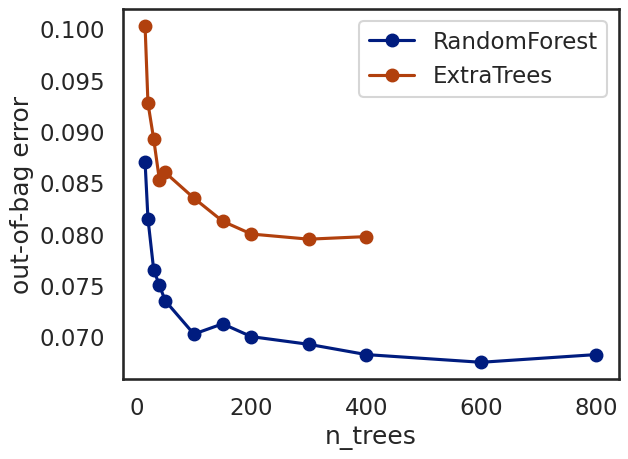

In [ ]:
sns.set_context('talk')
sns.set_palette('dark')
sns.set_style('white')

ax = oob_df.plot(marker='o')
ax.set(ylabel='out-of-bag error');

In [ ]:
#Perform evaluation model in Extra Trees
etc = ExtraTreesClassifier(random_state= 42)


In [ ]:
#Perform Gridsearch
grid_search_etc = GridSearchCV(estimator=etc, param_grid=param_grid, cv= 5)
grid_search_etc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ExtraTreesClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 500]})

In [ ]:
grid_search_etc.best_params_

{'criterion': 'gini',
 'max_depth': 30,
 'max_features': 'sqrt',
 'n_estimators': 500}

In [ ]:
grid_search_etc.best_score_

0.9275

In [ ]:
#Perform RandomizedSearch
random_search_etc = RandomizedSearchCV(estimator=etc, param_distributions=param_dist,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1)
random_search_etc.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3, estimator=ExtraTreesClassifier(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=42, verbose=2)

In [ ]:
random_search_etc.best_params_

{'n_estimators': 800,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 70,
 'bootstrap': False}

In [ ]:
random_search_etc.best_score_

0.9237502404086778

Results for Grid Search
Training Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3434
        True       1.00      1.00      1.00       566

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

Testing Accuracy: 0.9240
Testing Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.99      0.96       859
        True       0.92      0.50      0.65       141

    accuracy                           0.92      1000
   macro avg       0.92      0.75      0.80      1000
weighted avg       0.92      0.92      0.91      1000

Confusion Matrix (Test Set) for Grid:
[[853   6]
 [ 70  71]]
AUC-ROC (Test Set) for Grid: 0.8434


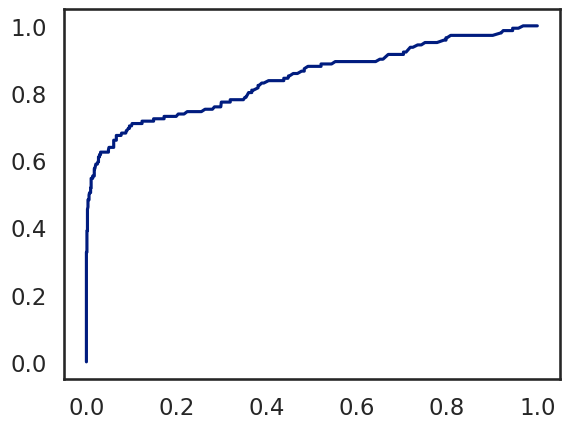

In [ ]:
#Evaluate the GridSearch CV model
evaluate_model(grid_search_etc, X_train, X_test, y_train, y_test, 'Grid')


Results for Random Search
Training Accuracy: 1.0000
Training Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3434
        True       1.00      1.00      1.00       566

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

Testing Accuracy: 0.9260
Testing Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.99      0.96       859
        True       0.94      0.51      0.66       141

    accuracy                           0.93      1000
   macro avg       0.93      0.75      0.81      1000
weighted avg       0.93      0.93      0.92      1000

Confusion Matrix (Test Set) for Random:
[[854   5]
 [ 69  72]]
AUC-ROC (Test Set) for Random: 0.8401


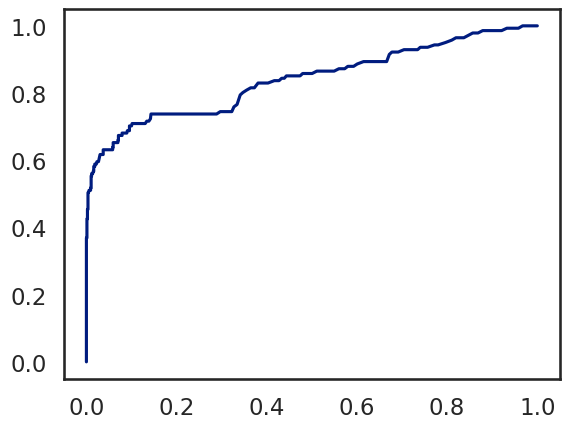

In [ ]:
#Evaluate RandomizedSearch model
evaluate_model(random_search_etc, X_train, X_test, y_train, y_test, "Random")

###**Interpretation**

In this activity we evaluate the ExtraTrees model performance and find the best parameters using GridSearchCV and RandomizedSearch. As we get to the accuracy of the training and testing, I notice that the GridSearchCV got a 1.0 accuracy on training and  0.9240 on testing. Thus, it suggest that our model is prone to overfit and  misclassify some datapoints. Meanwhile, using  the Randomized Search we got a training accuracy of 1 and a testing accuracy of 0.9260 which is slightly better than the GridSearch result. The overfitting of the model is likely because of the imbalance of our dataset. Overall the AUC-ROC score of our model is around 0.84 which suggest that our model performance is good in classifying the two target on our Orange Telecom Churn data.

## Question 5

* Select one of the models that performs well and calculate error metrics and a confusion matrix on the test data set.
* Given the distribution of the predicted class, which metric is most important? Which could be deceiving?

In [ ]:
# Random forest with 100 estimators
model = RF.set_params(n_estimators=600)

y_pred = model.predict(X_test)

Unsurprisingly, recall is rather poor for the customers who churned (True) class since they are quite small. We are doing better than random guessing, though, as the accuracy is 0.932 (vs 0.85 for random guessing).

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

cr = classification_report(y_test, y_pred)
print(cr)

score_df = pd.DataFrame({'accuracy': accuracy_score(y_test, y_pred),
                         'precision': precision_score(y_test, y_pred),
                         'recall': recall_score(y_test, y_pred),
                         'f1': f1_score(y_test, y_pred),
                         'auc': roc_auc_score(y_test, y_pred)},
                         index=pd.Index([0]))

print(score_df)

              precision    recall  f1-score   support

       False       0.93      0.99      0.96       859
        True       0.91      0.56      0.69       141

    accuracy                           0.93      1000
   macro avg       0.92      0.78      0.83      1000
weighted avg       0.93      0.93      0.92      1000

   accuracy  precision    recall        f1       auc
0      0.93   0.908046  0.560284  0.692982  0.775485


In [ ]:
model = RF.set_params(n_estimators=800)

In [ ]:

y_pred2 = model.predict(X_train)

In [ ]:
cr = classification_report(y_train, y_pred2)
print(cr)


              precision    recall  f1-score   support

       False       1.00      1.00      1.00      3434
        True       1.00      1.00      1.00       566

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [ ]:

score_df = pd.DataFrame({'accuracy': accuracy_score(y_train, y_pred2),
                         'precision': precision_score(y_train, y_pred2),
                         'recall': recall_score(y_train, y_pred2),
                         'f1': f1_score(y_train, y_pred2),
                         'auc': roc_auc_score(y_train, y_pred2)},
                         index=pd.Index([0]))

score_df


,accuracy,precision,recall,f1,auc
0,1.0,1.0,1.0,1.0,1.0


## Question 6

* Print or visualize the confusion matrix.
* Plot the ROC-AUC and precision-recall curves.
* Plot the feature importances.

Text(0.5, 6.8833333333333275, 'Ground Truth')

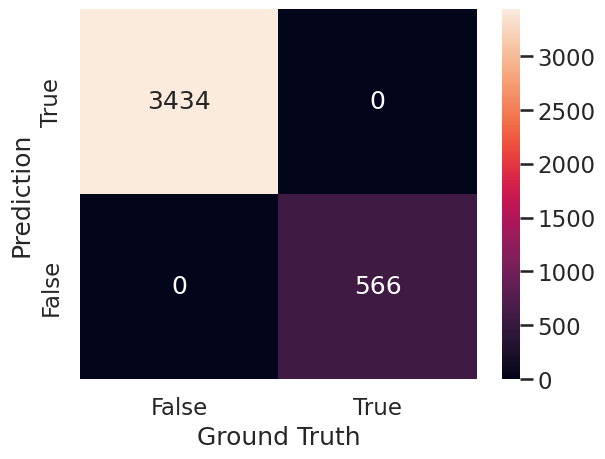

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

sns.set_context('talk')
cm = confusion_matrix(y_train, y_pred2)
ax = sns.heatmap(cm, annot=True, fmt='d')

labels = ['False', 'True']
ax.set_xticklabels(labels);
ax.set_yticklabels(labels[::-1]);
ax.set_ylabel('Prediction');
ax.set_xlabel('Ground Truth')

The ROC-AUC and precision-recall curves.

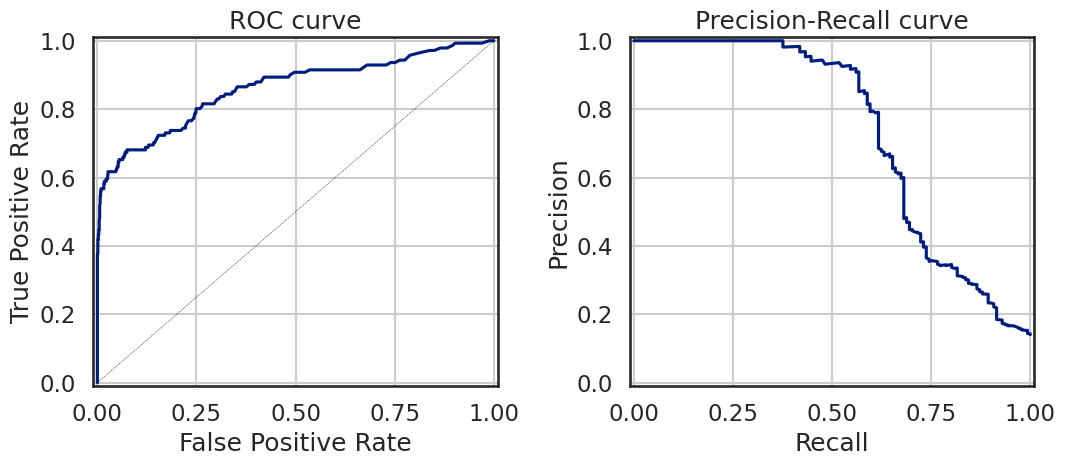

In [ ]:
sns.set_context('talk')

fig, axList = plt.subplots(ncols=2)
fig.set_size_inches(11, 5)

# Get the probabilities for each of the two categories
y_prob = model.predict_proba(X_test)

# Plot the ROC-AUC curve
ax = axList[0]

fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1])
ax.plot(fpr, tpr)
# It is customary to draw a diagonal dotted line in ROC plots.
# This is to indicate completely random prediction. Deviation from this
# dotted line towards the upper left corner signifies the power of the model.
ax.plot([0, 1], [0, 1], ls='--', color='black', lw=.3)
ax.set(xlabel='False Positive Rate',
       ylabel='True Positive Rate',
       xlim=[-.01, 1.01], ylim=[-.01, 1.01],
       title='ROC curve')
ax.grid(True)

# Plot the precision-recall curve
ax = axList[1]

precision, recall, _ = precision_recall_curve(y_test, y_prob[:,1])
ax.plot(recall, precision)
ax.set(xlabel='Recall', ylabel='Precision',
       xlim=[-.01, 1.01], ylim=[-.01, 1.01],
       title='Precision-Recall curve')
ax.grid(True)

plt.tight_layout()

The feature importances. Total daily cost is the biggest predictor of customer churn.

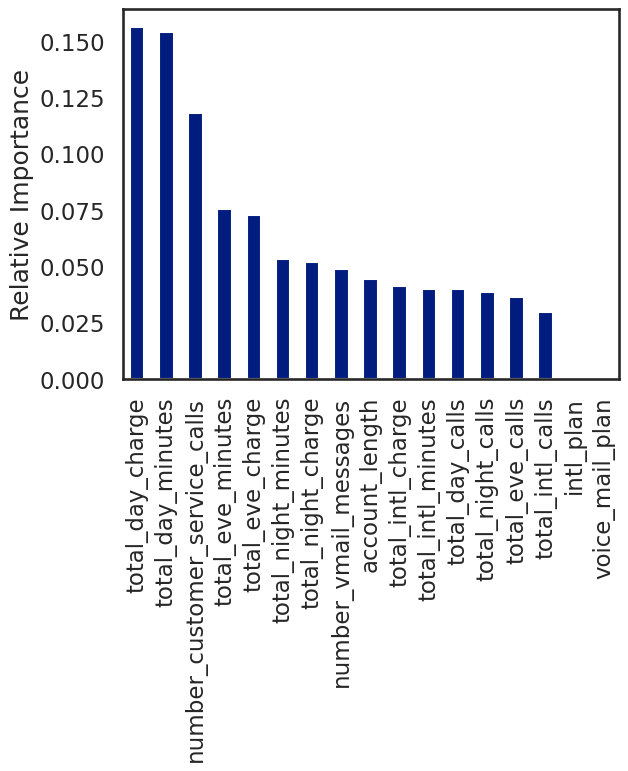

In [ ]:
feature_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

ax = feature_imp.plot(kind='bar')
ax.set(ylabel='Relative Importance');

## Conclusion:
In this activity, I learned how  random forest and extra trees work on the data. We also got to evaluate the model performance and compare each accuracy based on the given parameters using GridSearchCV and Randomized Search. We also plot the importances features that can affect to the prediction of our model.
